In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
import pickle

df = pd.read_csv("Rainfall.csv")
df.head()
df.tail()
df.describe()
# df.info()
# df.index
df.columns
df.isnull().sum()
# df.duplicated().sum()
df.head()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,2,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,3,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,4,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,5,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7


In [2]:
df["day"].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

In [3]:
df.columns = df.columns.str.strip()
df.drop_duplicates(inplace=True)
df.drop(columns="day",inplace=True)
df["rainfall"].replace({"yes":1,"no" : 0},inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_12872\1742626102.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["rainfall"].replace({"yes":1,"no" : 0},inplace=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_12872\1742626102.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["rainfall"].repla

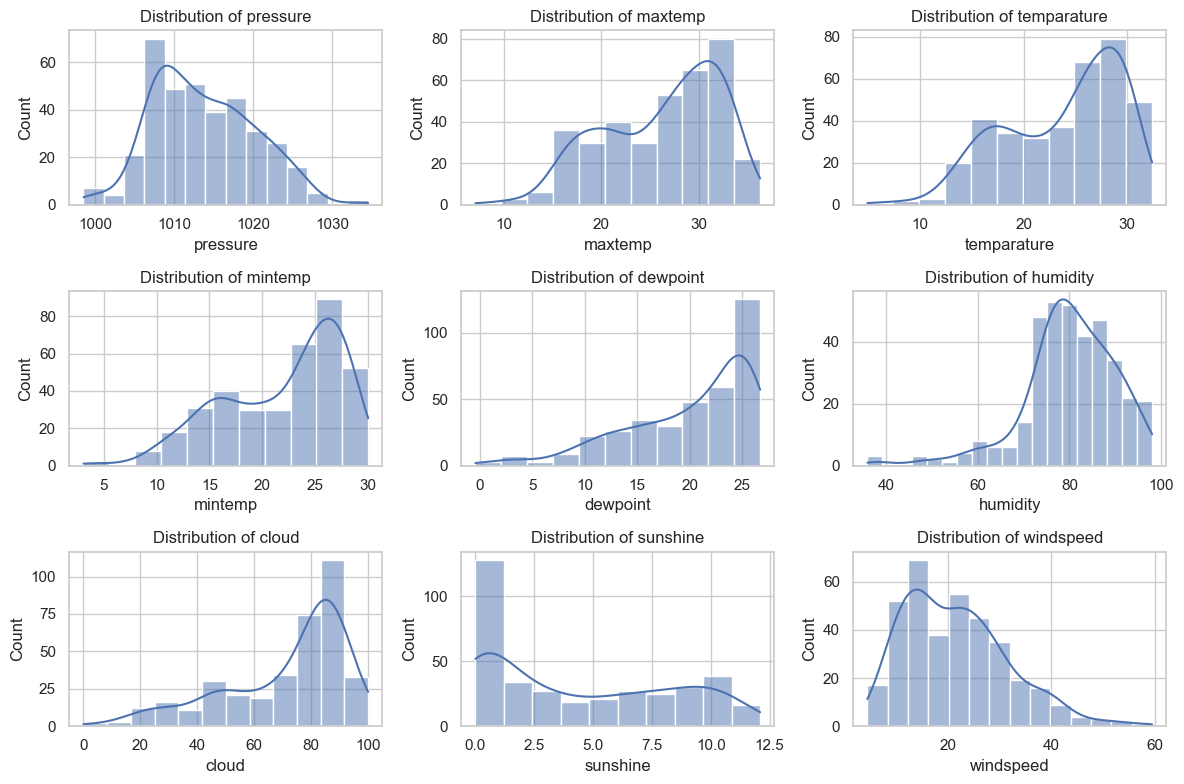

In [4]:
sns.set(style="whitegrid")
plt.figure(figsize=(12,8))
df.columns
for i,column in enumerate(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity','cloud', 'sunshine','windspeed'],1):
    plt.subplot(3,3,i)
    sns.histplot(df[column],kde=True)
    plt.title(f"Distribution of {column}")
    plt.tight_layout()
    
    

Text(0.5, 1.0, 'Correlation Heatmap')

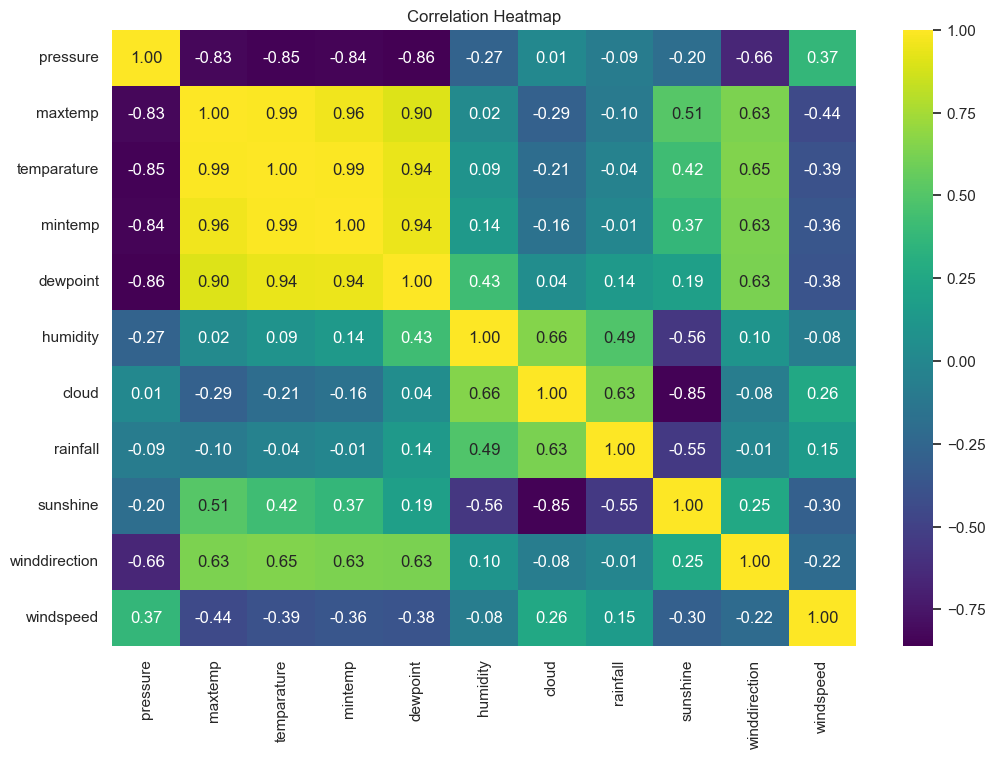

In [5]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True,cmap="viridis",fmt=".2f")
plt.title("Correlation Heatmap")

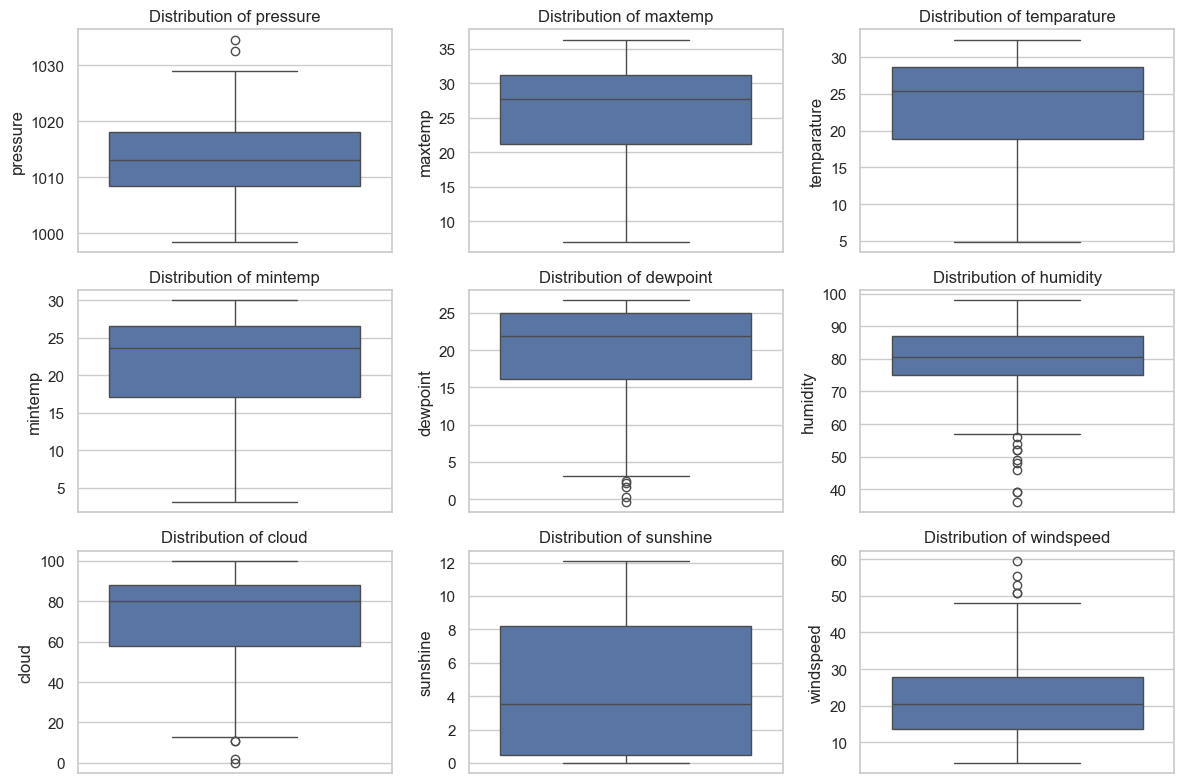

In [6]:
plt.figure(figsize=(12,8))
df.columns
for i,column in enumerate(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity','cloud', 'sunshine','windspeed'],1):
    plt.subplot(3,3,i)
    sns.boxplot(df[column])
    plt.title(f"Distribution of {column}")
    plt.tight_layout()

In [7]:
df = df.drop(columns=['maxtemp', 'temparature', 'mintemp'])

In [8]:
df["rainfall"].value_counts()

rainfall
1    249
0    117
Name: count, dtype: int64

In [9]:
df_majority = df[df["rainfall"] == 1]
df_minority = df[df["rainfall"] == 0]
df_majority.shape
df_minority.shape

(117, 8)

In [10]:
df_majority_down_sample = resample(df_majority,replace=True,n_samples=len(df_minority) ,random_state=2)

In [11]:
df_majority_down_sample.shape
final_sample = pd.concat([df_majority_down_sample,df_minority])

In [12]:
final_sample.shape
final_sample.head()

,pressure,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
240,1006.5,24.4,79,84,1,4.5,210.0,8.9
22,1027.1,3.4,70,95,1,0.0,20.0,55.5
348,1016.6,17.3,82,84,1,0.4,50.0,20.3
106,1010.5,22.7,89,81,1,3.5,210.0,15.3
31,1022.2,11.2,93,96,1,0.0,20.0,31.9


In [13]:
final_sample = final_sample.sample(frac=1,random_state=42).reset_index(drop=True)

In [14]:
final_sample.head()

,pressure,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1025.3,13.3,78,86,1,1.2,20.0,20.9
1,1013.4,19.5,69,17,0,10.5,70.0,12.4
2,1006.1,24.4,74,27,0,10.8,220.0,8.7
3,1016.5,16.4,90,90,1,2.1,40.0,23.3
4,1021.2,8.4,66,18,0,10.1,20.0,24.4


In [15]:
final_sample["rainfall"].value_counts()
final_sample.to_csv("final_data.csv",index=False)